In [1]:
import pandas as pd

train_df = pd.read_parquet("hf://datasets/stanfordnlp/imdb/plain_text/train-00000-of-00001.parquet").sample(1000)
test_df = pd.read_parquet("hf://datasets/stanfordnlp/imdb/plain_text/test-00000-of-00001.parquet").sample(1000)

In [2]:
train_df.head()

,text,label
12544,A few years ago I added a comment to the IMDB ...,1
11819,If you haven't figured out what is going to ha...,0
24178,if you have a chance of seeing this film do se...,1
9731,Discovery Channel/Animal Planet must be ashame...,0
18860,"This movie is very hilarious, and it has a gre...",1


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score

In [4]:
model = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('clf', LogisticRegression()),
])

model.fit(train_df['text'], train_df['label'])

/home/tiago/insper/nlp_course/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('vectorizer', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [5]:
y_pred = model.predict(test_df['text'])
acc = accuracy_score(y_pred, test_df['label'])
print(acc)

0.802


# Exemplo no PyTorch

In [6]:
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(train_df['text']).toarray()
X_test = vectorizer.transform(test_df['text']).toarray()

In [7]:
import torch.nn as nn
import torch
import torch.nn.functional as F
from tqdm import tqdm 

In [8]:
X_tensor_train = torch.tensor(X_train).float()
X_tensor_test = torch.tensor(X_test).float()
y_tensor_train = torch.tensor(train_df['label'].values).float().reshape( (-1,1) )
y_tensor_test = torch.tensor(test_df['label'].values).float().reshape( (-1,1) )

In [9]:
X_tensor_train.shape

torch.Size([1000, 18246])

In [10]:
model = nn.Linear(
    in_features=X_tensor_train.shape[1],
    out_features=1,
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)  # lr is the learning rate - this is our alpha

print("Entering loop")
# And now, this is the training loop:
losses = []
for epoch in tqdm(range(10000)):
    optimizer.zero_grad()
    z_pred = model(X_tensor_train)
    loss = F.binary_cross_entropy_with_logits(z_pred, y_tensor_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

Entering loop


100%|██████████| 10000/10000 [01:23<00:00, 120.14it/s]


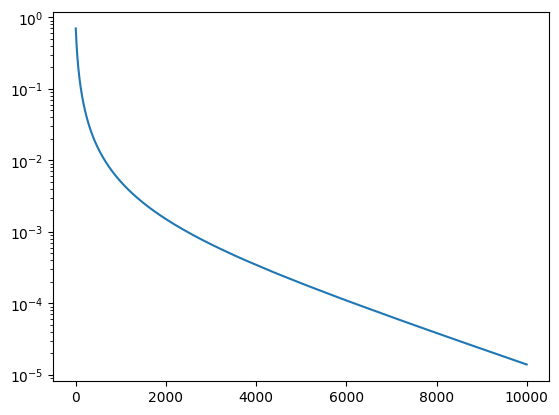

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(losses)
plt.semilogy()
plt.show()

In [16]:
z_pred = model(X_tensor_test)
y_class = z_pred > 0.5
y_np = y_class.numpy()

In [17]:
accuracy_score(y_np, test_df['label'])

0.751

In [ ]:
import re 

def calcular_vocabulario(textos : list[str]):
    vocabulario = []
    for s in textos:
        palavras = re.findall(r'\w\w+', s.upper())
        vocabulario.extend(palavras)
    return set(vocabulario)

vocabulario = calcular_vocabulario(list(train_df['text']))

def calcular_mapeamento(vocabulario : set[str]):
    mapa = {}
    id = 1
    for w in vocabulario:
        mapa[w] = id
        id += 1
    return mapa

mapa = calcular_mapeamento(vocabulario=vocabulario)
print(mapa)

{'ANTIQUITIES': 1, 'MERCILESSLY': 2, 'JEERS': 3, 'VETERAN': 4, 'PASSENGER': 5, 'SAW': 6, 'PENNY': 7, 'REPRISES': 8, 'FANTASIES': 9, 'FANNY': 10, 'SHIRLEY': 11, 'FREAKISH': 12, 'EVERYTHING': 13, 'SPARKLING': 14, 'JONESY': 15, 'MODESTY': 16, 'BUTTERFLIES': 17, 'ASTOUNDING': 18, 'IDEOLOGICAL': 19, 'SELL': 20, 'UNDERPLAYING': 21, 'FRIEL': 22, 'SOAKING': 23, 'BROCK': 24, 'TERRIFYING': 25, 'GENEROUS': 26, 'DOCTOR': 27, 'CUSTOMERS': 28, 'COBURG': 29, 'COCKNEY': 30, 'MERK': 31, 'ELECTRIFYING': 32, 'HAPPENS': 33, 'SOOOO': 34, 'CONVENTION': 35, 'PIGTAILED': 36, 'POLITICALLY': 37, 'INDICATE': 38, 'WILLIAN': 39, 'PASTICHE': 40, 'FREAKED': 41, 'RELATIVES': 42, 'LYING': 43, 'PLUM': 44, 'PAPERS': 45, 'CONTINUING': 46, 'VILE': 47, 'STALKED': 48, 'RUMMAGING': 49, 'HAPPILY': 50, 'TOBY': 51, 'LAURIE': 52, 'TNG': 53, 'PASDAR': 54, 'HEARTEDLY': 55, 'TESTI': 56, 'SHELVES': 57, 'SINGIN': 58, 'UPTIGHT': 59, 'OUTDATED': 60, 'DAUGHTER': 61, 'INVITES': 62, 'MODERNE': 63, 'ATHELNY': 64, 'DEVGAN': 65, 'GARETH': 66

In [56]:
def converter_string(texto_de_entrada, mapa, tamanho_saida):
    saida = []
    for s in re.findall(r'\w\w+', texto_de_entrada.upper()):
        if s in mapa:
            saida.append(mapa[s])
        
    if len(saida) < tamanho_saida:
        saida.extend( [0] * (tamanho_saida-len(saida)))
    if len(saida) > tamanho_saida:
        saida = saida[0:tamanho_saida]
    return saida

converter_string("I like this movie ANTIQUITIES MERCILESSLY", mapa, 10)

[6287, 18238, 16373, 1, 2, 0, 0, 0, 0, 0]

In [57]:
mapa['MOVIE']

16373

In [58]:
class MinhaClasse:
    def __init__(self, test):
        print(test)
        self.string = test
    
    def meu_metodo(self):
        print(self.string)
        

x = MinhaClasse("minha string")

y = MinhaClasse("outra string")
x.meu_metodo()
y.meu_metodo()

minha string
outra string
minha string
outra string


In [59]:
class ClassificadorComEmbedding(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, n_outputs=1):
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=num_embeddings,
            embedding_dim=embedding_dim,
        )
        
        self.linear = nn.Linear(
            in_features = embedding_dim,
            out_features=n_outputs
        )
    
    def forward(self, X):
        Xe = self.embedding(X)
        Xp = torch.mean(Xe, dim=1)
        z = self.linear(Xp)
        return z

In [60]:
def tokenizacao(meu_dataset: list[str], mapa, n_tokens):
    saida = []
    for s in meu_dataset:
        saida.append(converter_string(s, mapa, n_tokens))
    return torch.tensor(saida)


toy_data = [
    "this is one way to say it",
    "this is another way to say it movie movie movie",
]




In [61]:

model(x)

TypeError: embedding(): argument 'indices' (position 2) must be Tensor, not MinhaClasse

In [62]:
X_train = tokenizacao(train_df['text'], mapa, 100)
model = ClassificadorComEmbedding(20000, 2, 1)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)  # lr is the learning rate - this is our alpha

print("Entering loop")
# And now, this is the training loop:
losses = []
for epoch in tqdm(range(10000)):
    optimizer.zero_grad()
    z_pred = model(X_train)
    loss = F.binary_cross_entropy_with_logits(z_pred, y_tensor_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

Entering loop


100%|██████████| 10000/10000 [01:37<00:00, 102.40it/s]


In [63]:
X_test_tokens = tokenizacao(test_df['text'], mapa, 100)
z_test = model(X_test_tokens)
y_test_pred = z_test > 0.5
y_test_pred_np = y_test_pred.numpy().reshape(-1)
accuracy_score(y_test_pred_np, test_df['label'])


0.689